# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import os
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty

In [2]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [3]:
# Enable CUDA if available
os.environ['MLP_USE_CUDA'] = '1'

# Mac

In [4]:
os.environ['MLP_DATA_DIR'] = r"/Users/ace0t/Documents/UoE/mlpractical/data"

# Windows

In [5]:
os.environ['MLP_DATA_DIR'] = r"C:\Users\andre\Documents\UoE\mlpractical\data"

In [6]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile 'C:\\Users\\andre\\Documents\\UoE\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\andre\\Documents\\UoE\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


In [7]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 1e-3
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 32 # changed hidden dim to 32

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# how do I turn off this logging?

# Remember to use notebook=False when you write a script to be run in a terminal
stats_32, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

fig_1.savefig('mlp_cw1_emnist_32_hidden_error.pdf')
fig_2.savefig('mlp_cw1_emnist_32_hidden_accuracy.pdf')
grad_plot.savefig('mlp_cw1_emnist_32_hidden_gradflow.pdf')

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.6s to complete
    error(train)=1.23e+00, acc(train)=6.58e-01, error(valid)=1.24e+00, acc(valid)=6.55e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.6s to complete
    error(train)=1.10e+00, acc(train)=6.92e-01, error(valid)=1.11e+00, acc(valid)=6.84e-01


...

Epoch 3: 0.6s to complete
    error(train)=1.02e+00, acc(train)=7.09e-01, error(valid)=1.04e+00, acc(valid)=7.05e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 0.6s to complete
    error(train)=9.66e-01, acc(train)=7.25e-01, error(valid)=9.91e-01, acc(valid)=7.13e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.4s to complete
    error(train)=1.05e+00, acc(train)=7.03e-01, error(valid)=1.07e+00, acc(valid)=6.97e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.4s to complete
    error(train)=8.62e-01, acc(train)=7.51e-01, error(valid)=8.91e-01, acc(valid)=7.44e-01


...

Epoch 98: 0.4s to complete
    error(train)=3.38e-01, acc(train)=8.83e-01, error(valid)=6.68e-01, acc(valid)=8.09e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.4s to complete
    error(train)=3.40e-01, acc(train)=8.81e-01, error(valid)=6.72e-01, acc(valid)=8.09e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.3s to complete
    error(train)=3.50e-01, acc(train)=8.78e-01, error(valid)=6.78e-01, acc(valid)=8.07e-01


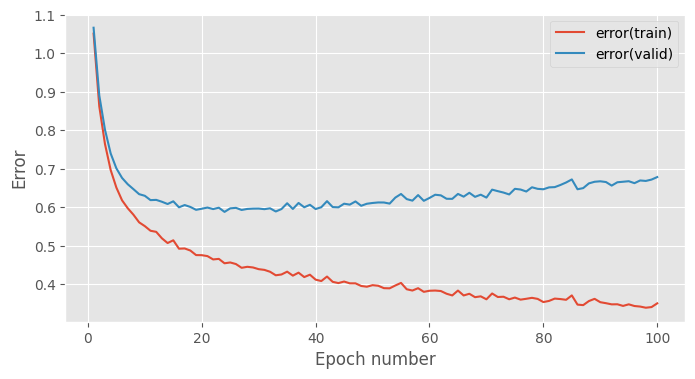

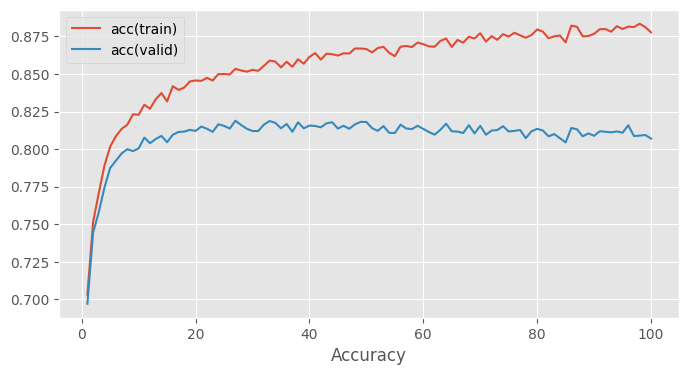

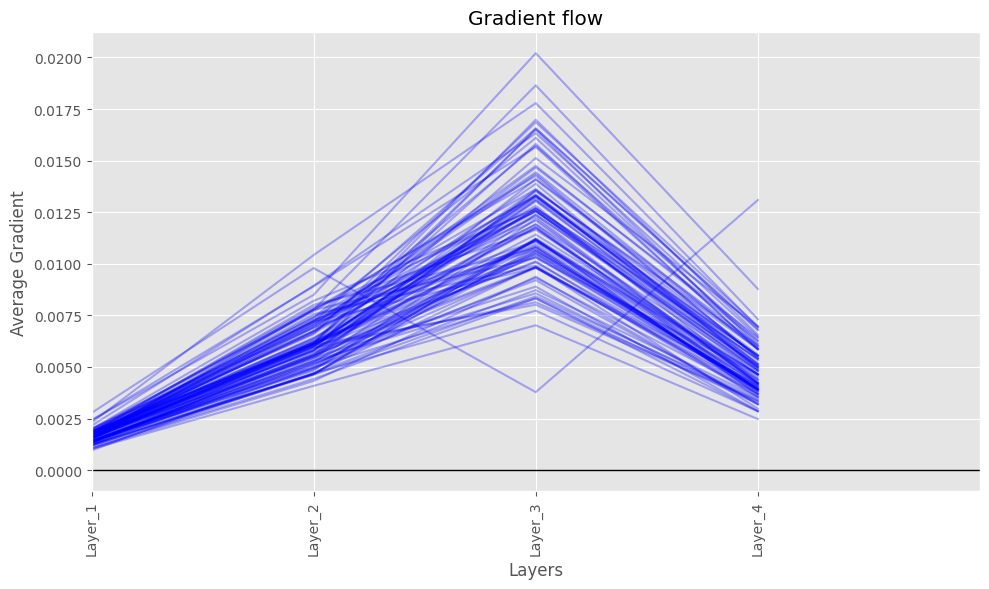

In [7]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 1e-3
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 64 # changed hidden dim to 64

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_64, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
fig_1.savefig('mlp_cw1_emnist_64_hidden_error.pdf')
fig_2.savefig('mlp_cw1_emnist_64_hidden_accuracy.pdf')
grad_plot.savefig('mlp_cw1_emnist_64_hidden_gradflow.pdf')

# 128 hidden units 1 layer

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.5s to complete
    error(train)=8.89e-01, acc(train)=7.46e-01, error(valid)=9.06e-01, acc(valid)=7.44e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.6s to complete
    error(train)=7.03e-01, acc(train)=7.86e-01, error(valid)=7.38e-01, acc(valid)=7.77e-01


...

Epoch 98: 0.5s to complete
    error(train)=1.58e-01, acc(train)=9.40e-01, error(valid)=9.42e-01, acc(valid)=8.06e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.5s to complete
    error(train)=1.54e-01, acc(train)=9.41e-01, error(valid)=9.48e-01, acc(valid)=8.06e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.5s to complete
    error(train)=1.59e-01, acc(train)=9.39e-01, error(valid)=9.58e-01, acc(valid)=8.04e-01


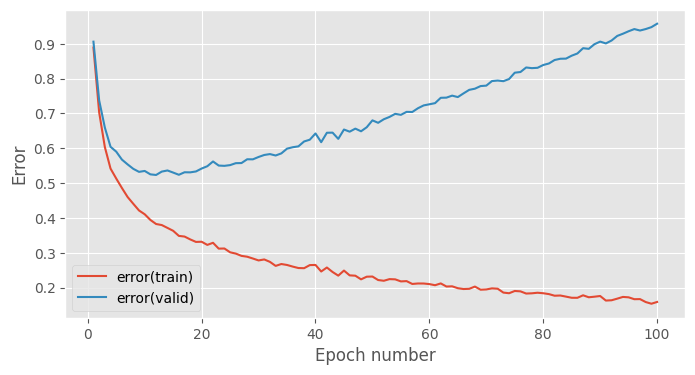

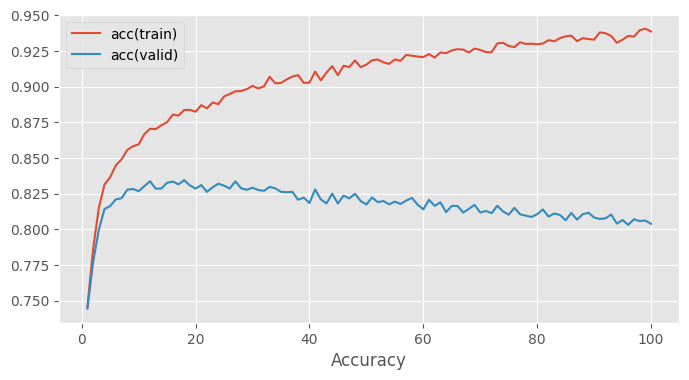

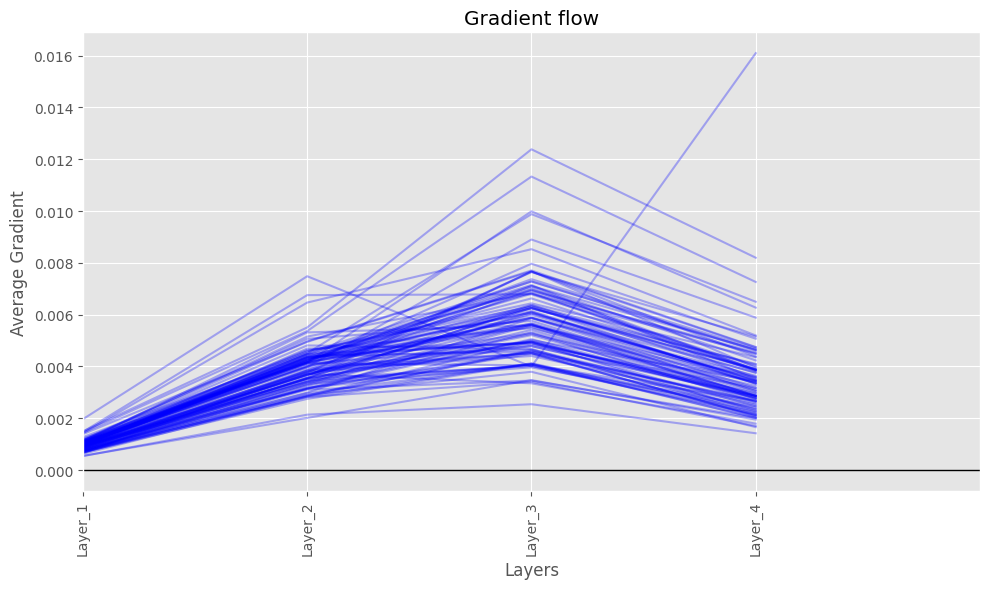

In [8]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 1e-3
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_128, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
fig_1.savefig('mlp_cw1_emnist_128_hidden_error.pdf')
fig_2.savefig('mlp_cw1_emnist_128_hidden_accuracy.pdf')
grad_plot.savefig('mlp_cw1_emnist_128_hidden_gradflow.pdf')

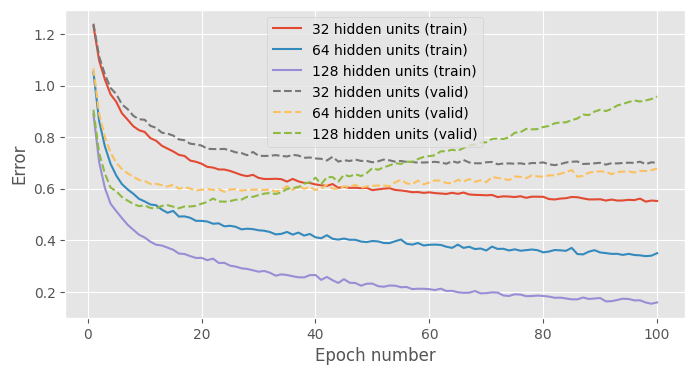

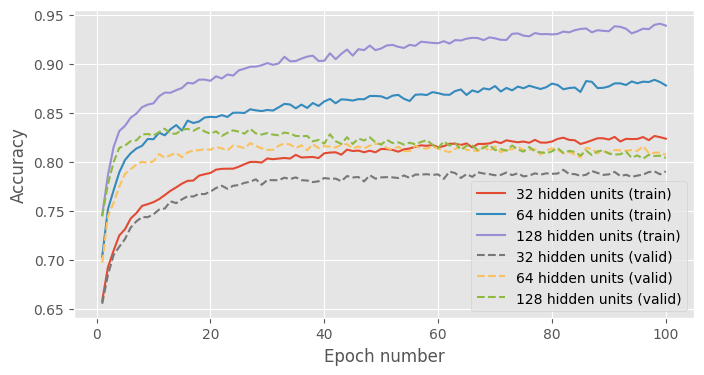

In [9]:
# plotting 32 vs 64 vs 128 hidden units

fig, ax = plt.subplots(1,1, figsize=(8,4))
# Plot training error for reference
ax.plot(np.arange(1, stats_32.shape[0]) * stats_interval, 
          stats_32[1:, keys['error(train)']], label='32 hidden units (train)')
ax.plot(np.arange(1, stats_64.shape[0]) * stats_interval,
            stats_64[1:, keys['error(train)']], label='64 hidden units (train)')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval,
            stats_128[1:, keys['error(train)']], label='128 hidden units (train)')
ax.plot(np.arange(1, stats_32.shape[0]) * stats_interval, 
          stats_32[1:, keys['error(valid)']], label='32 hidden units (valid)', linestyle='--')
ax.plot(np.arange(1, stats_64.shape[0]) * stats_interval,
            stats_64[1:, keys['error(valid)']], label='64 hidden units (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval,
            stats_128[1:, keys['error(valid)']], label='128 hidden units (valid)', linestyle='--')
ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Error')

fig.savefig('mlp_cw1_emnist_hidden_units_comparison_error.pdf')
# Separate into different plot for accuracy
fig, ax = plt.subplots(1,1, figsize=(8,4))



# plot training accuracy for reference
ax.plot(np.arange(1, stats_32.shape[0]) * stats_interval, 
          stats_32[1:, keys['acc(train)']], label='32 hidden units (train)')
ax.plot(np.arange(1, stats_64.shape[0]) * stats_interval,
            stats_64[1:, keys['acc(train)']], label='64 hidden units (train)')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval,
            stats_128[1:, keys['acc(train)']], label='128 hidden units (train)')
ax.plot(np.arange(1, stats_32.shape[0]) * stats_interval, 
          stats_32[1:, keys['acc(valid)']], label='32 hidden units (valid)', linestyle='--')
ax.plot(np.arange(1, stats_64.shape[0]) * stats_interval,
            stats_64[1:, keys['acc(valid)']], label='64 hidden units (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval,
            stats_128[1:, keys['acc(valid)']], label='128 hidden units (valid)', linestyle='--')
ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Accuracy')

fig.savefig('mlp_cw1_emnist_hidden_units_comparison_accuracy.pdf')


# 128 hidden units 2 layer

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.7s to complete
    error(train)=7.53e-01, acc(train)=7.65e-01, error(valid)=7.76e-01, acc(valid)=7.57e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.7s to complete
    error(train)=5.93e-01, acc(train)=8.10e-01, error(valid)=6.32e-01, acc(valid)=7.97e-01


...

Epoch 98: 0.8s to complete
    error(train)=1.01e-01, acc(train)=9.59e-01, error(valid)=1.54e+00, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.7s to complete
    error(train)=1.00e-01, acc(train)=9.60e-01, error(valid)=1.57e+00, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.8s to complete
    error(train)=9.31e-02, acc(train)=9.62e-01, error(valid)=1.53e+00, acc(valid)=8.18e-01


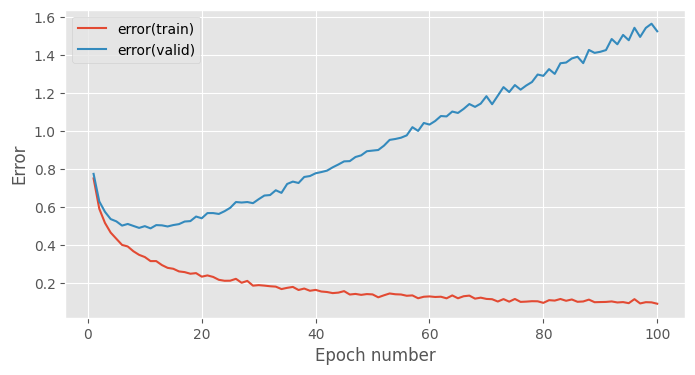

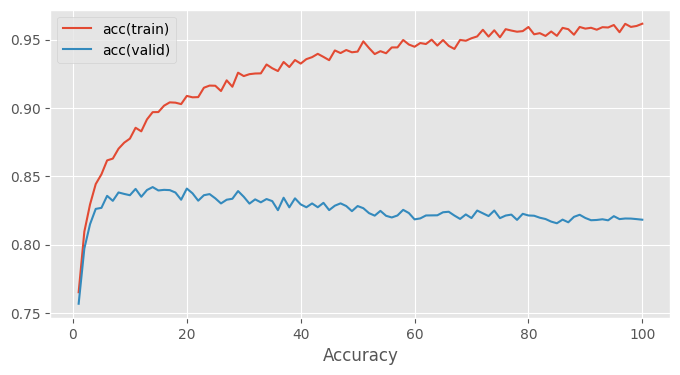

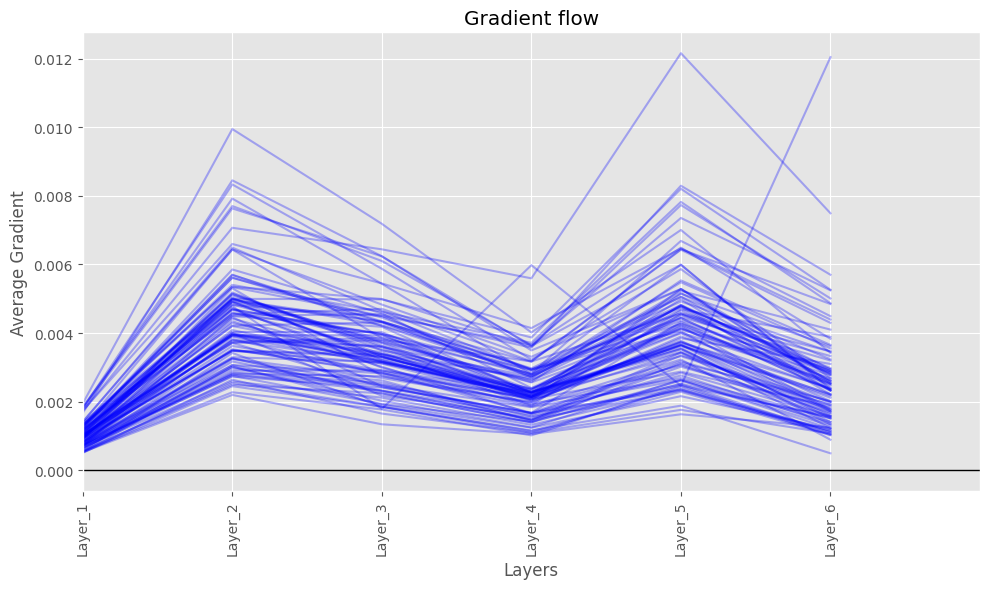

In [10]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 1e-3
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_128_2, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

fig_1.savefig('mlp_cw1_emnist_128_2hidden_error.pdf')
fig_2.savefig('mlp_cw1_emnist_128_2hidden_accuracy.pdf')
grad_plot.savefig('mlp_cw1_emnist_128_2hidden_gradflow.pdf')

# 128 hidden units 3 layer

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.9s to complete
    error(train)=7.08e-01, acc(train)=7.77e-01, error(valid)=7.38e-01, acc(valid)=7.69e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.8s to complete
    error(train)=5.39e-01, acc(train)=8.24e-01, error(valid)=5.86e-01, acc(valid)=8.10e-01


...

Epoch 98: 0.8s to complete
    error(train)=1.05e-01, acc(train)=9.59e-01, error(valid)=1.62e+00, acc(valid)=8.25e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 0.9s to complete
    error(train)=1.12e-01, acc(train)=9.57e-01, error(valid)=1.67e+00, acc(valid)=8.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 0.9s to complete
    error(train)=1.17e-01, acc(train)=9.55e-01, error(valid)=1.68e+00, acc(valid)=8.23e-01


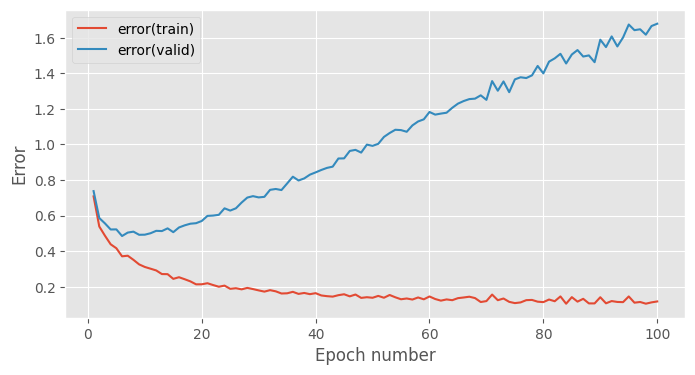

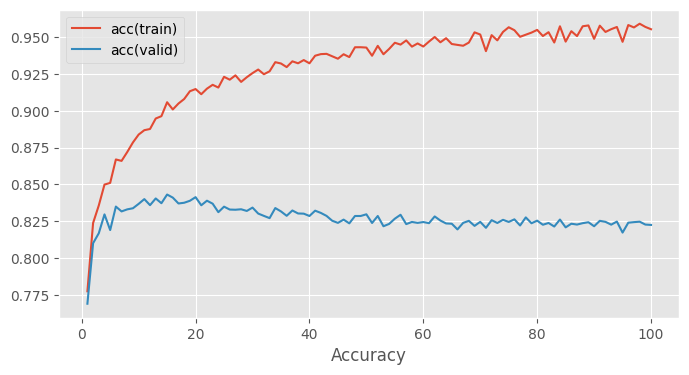

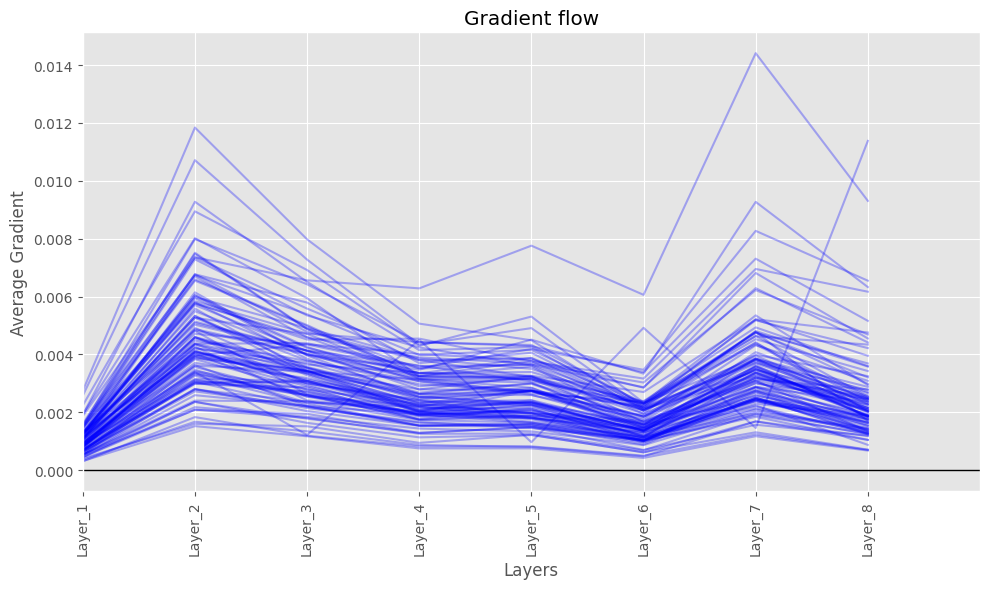

In [11]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 1e-3
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_128_3, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

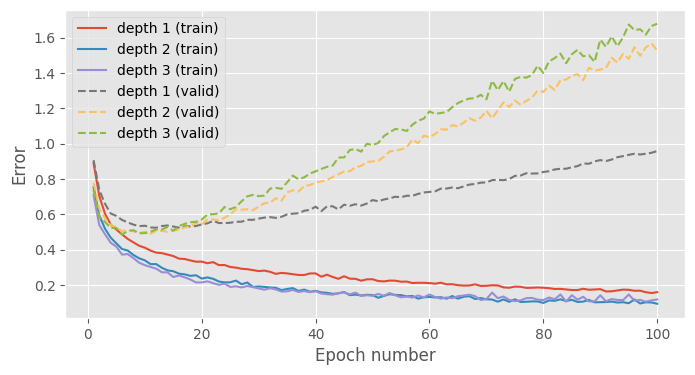

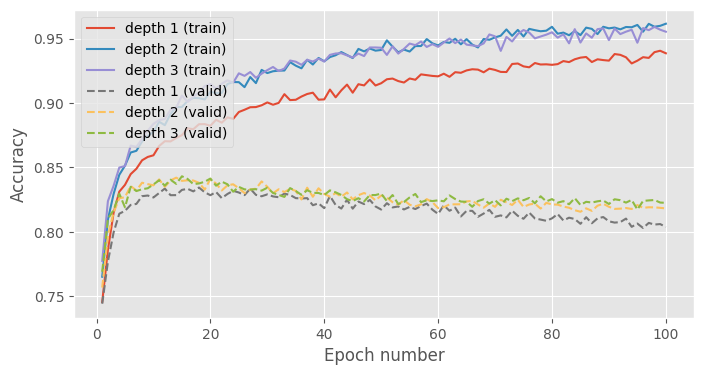

In [12]:
# plotting 128 hidden units with 1, 2 and 3 hidden layers

fig, ax = plt.subplots(1,1, figsize=(8,4))
# Plot training error for reference
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval, 
          stats_128[1:, keys['error(train)']], label='depth 1 (train)')
ax.plot(np.arange(1, stats_128_2.shape[0]) * stats_interval,
            stats_128_2[1:, keys['error(train)']], label='depth 2 (train)')
ax.plot(np.arange(1, stats_128_3.shape[0]) * stats_interval,
            stats_128_3[1:, keys['error(train)']], label='depth 3 (train)')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval, 
          stats_128[1:, keys['error(valid)']], label='depth 1 (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128_2.shape[0]) * stats_interval,
            stats_128_2[1:, keys['error(valid)']], label='depth 2 (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128_3.shape[0]) * stats_interval,
            stats_128_3[1:, keys['error(valid)']], label='depth 3 (valid)', linestyle='--')
ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Error')

fig.savefig('mlp_cw1_emnist_128_depth_comparison_error.pdf')

# Separate into different plot for accuracy
fig, ax = plt.subplots(1,1, figsize=(8,4))



# plot training accuracy for reference
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval, 
          stats_128[1:, keys['acc(train)']], label='depth 1 (train)')
ax.plot(np.arange(1, stats_128_2.shape[0]) * stats_interval,
            stats_128_2[1:, keys['acc(train)']], label='depth 2 (train)')
ax.plot(np.arange(1, stats_128_3.shape[0]) * stats_interval,
            stats_128_3[1:, keys['acc(train)']], label='depth 3 (train)')
ax.plot(np.arange(1, stats_128.shape[0]) * stats_interval, 
          stats_128[1:, keys['acc(valid)']], label='depth 1 (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128_2.shape[0]) * stats_interval,
            stats_128_2[1:, keys['acc(valid)']], label='depth 2 (valid)', linestyle='--')
ax.plot(np.arange(1, stats_128_3.shape[0]) * stats_interval,
            stats_128_3[1:, keys['acc(valid)']], label='depth 3 (valid)', linestyle='--')
ax.legend(loc=0)
ax.set_xlabel('Epoch number')
ax.set_ylabel('Accuracy')
fig.savefig('mlp_cw1_emnist_128_depth_comparison_accuracy.pdf')


# EMNIST Experiments

## Baseline

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 0.8s to complete
    error(train)=1.32e+00, acc(train)=6.31e-01, error(valid)=1.33e+00, acc(valid)=6.24e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 0.8s to complete
    error(train)=1.11e+00, acc(train)=6.86e-01, error(valid)=1.11e+00, acc(valid)=6.81e-01


...

Epoch 18: 0.8s to complete
    error(train)=5.09e-01, acc(train)=8.36e-01, error(valid)=5.64e-01, acc(valid)=8.21e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 19: 0.8s to complete
    error(train)=4.94e-01, acc(train)=8.42e-01, error(valid)=5.54e-01, acc(valid)=8.24e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 20: 0.8s to complete
    error(train)=4.88e-01, acc(train)=8.41e-01, error(valid)=5.52e-01, acc(valid)=8.22e-01


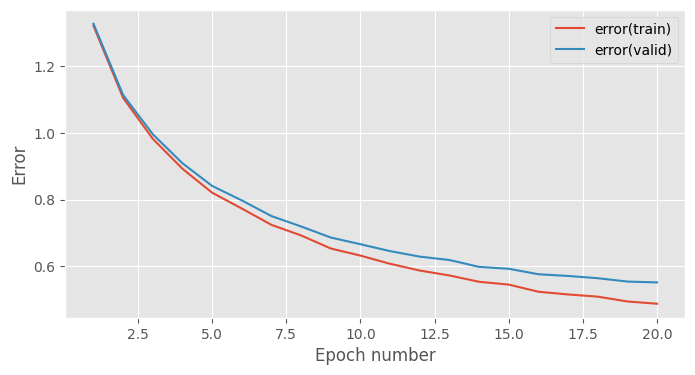

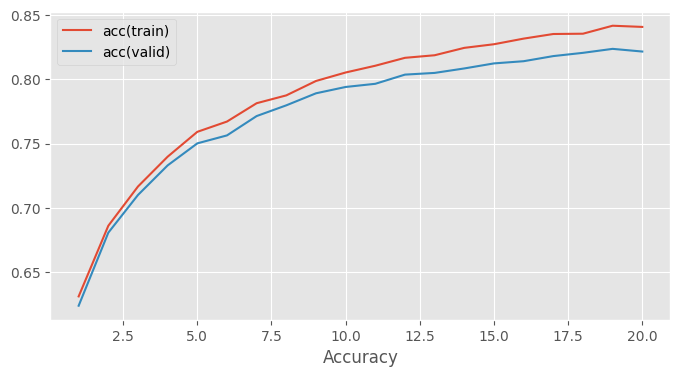

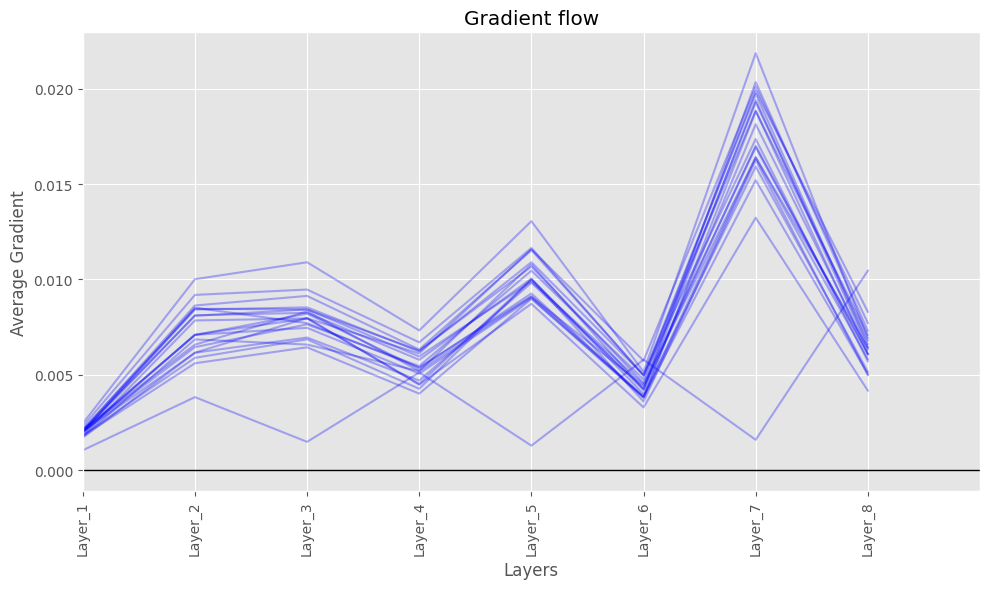

In [6]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_128_3, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Dropout

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.9s to complete
    error(train)=2.78e+00, acc(train)=3.54e-01, error(valid)=2.78e+00, acc(valid)=3.51e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.8s to complete
    error(train)=2.14e+00, acc(train)=4.75e-01, error(valid)=2.14e+00, acc(valid)=4.71e-01


...

Epoch 98: 1.7s to complete
    error(train)=5.53e-01, acc(train)=8.17e-01, error(valid)=5.99e-01, acc(valid)=8.04e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.7s to complete
    error(train)=5.51e-01, acc(train)=8.17e-01, error(valid)=5.98e-01, acc(valid)=8.03e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.7s to complete
    error(train)=5.48e-01, acc(train)=8.19e-01, error(valid)=5.94e-01, acc(valid)=8.05e-01


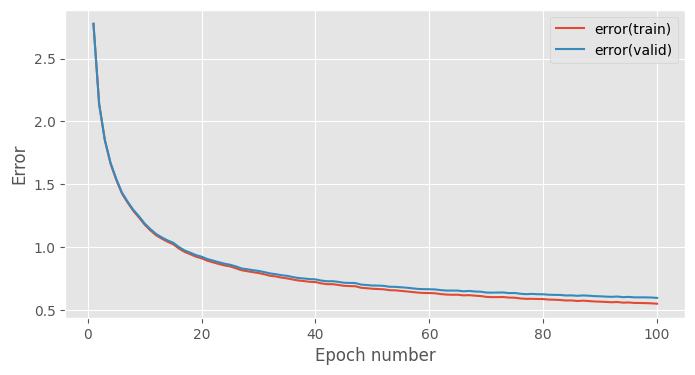

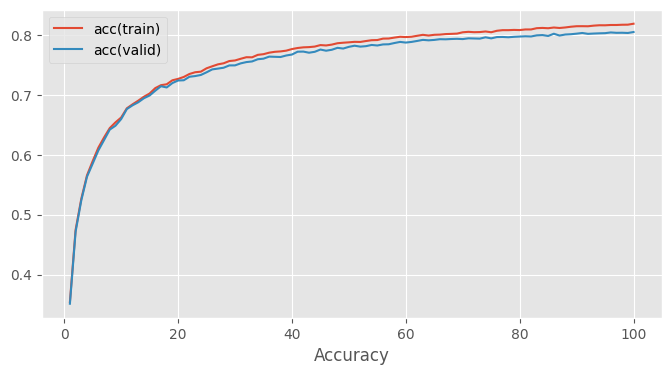

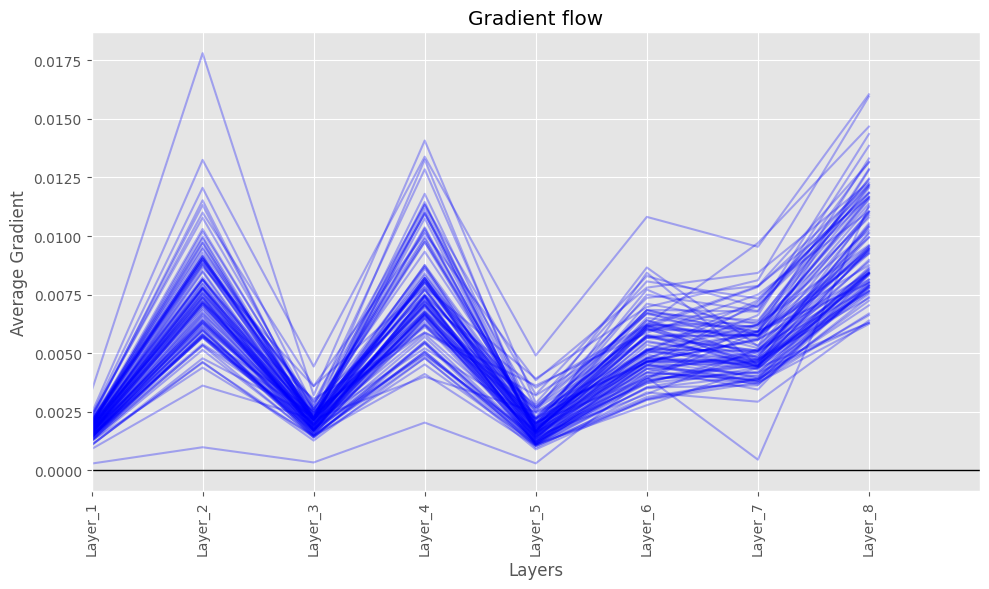

In [25]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

p = 0.6  # dropout probability

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after first hidden layer
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after second hidden layer
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after third hidden layer
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_Dropout, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## L1 Regularization

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.4s to complete
    error(train)=1.74e+00, acc(train)=5.43e-01, error(valid)=1.74e+00, acc(valid)=5.36e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.3s to complete
    error(train)=1.57e+00, acc(train)=5.83e-01, error(valid)=1.58e+00, acc(valid)=5.77e-01


...

Epoch 18: 1.4s to complete
    error(train)=1.19e+00, acc(train)=6.67e-01, error(valid)=1.19e+00, acc(valid)=6.64e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 19: 1.4s to complete
    error(train)=1.18e+00, acc(train)=6.68e-01, error(valid)=1.19e+00, acc(valid)=6.65e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 20: 1.3s to complete
    error(train)=1.17e+00, acc(train)=6.71e-01, error(valid)=1.18e+00, acc(valid)=6.67e-01


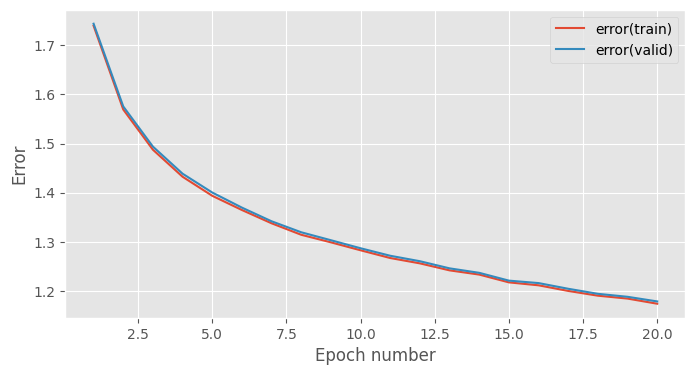

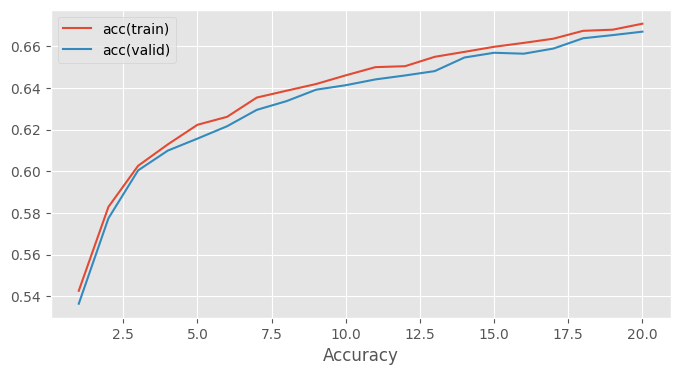

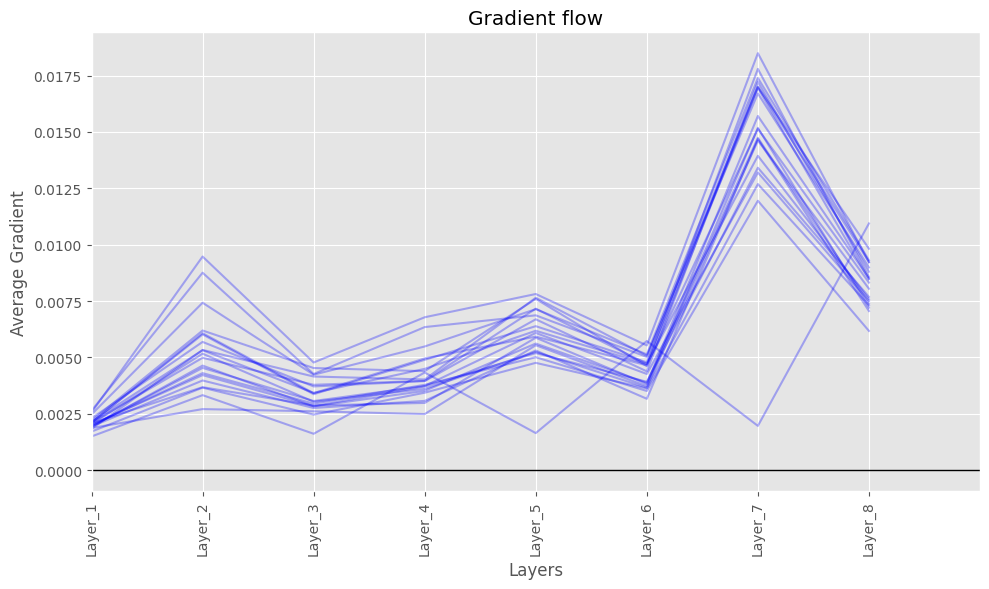

In [22]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 20
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_l1 = 0.001  # L1 coefficient
l1 = L1Penalty(lambda_l1)  # instantiate the L1 penalty

# Create model with THREE hidden layers and apply L1 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## L2 Regularization

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=1.34e+00, acc(train)=6.31e-01, error(valid)=1.33e+00, acc(valid)=6.28e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.8s to complete
    error(train)=1.11e+00, acc(train)=6.85e-01, error(valid)=1.11e+00, acc(valid)=6.81e-01


...

Epoch 98: 1.8s to complete
    error(train)=3.59e-01, acc(train)=8.81e-01, error(valid)=4.52e-01, acc(valid)=8.51e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.8s to complete
    error(train)=3.59e-01, acc(train)=8.80e-01, error(valid)=4.54e-01, acc(valid)=8.50e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.8s to complete
    error(train)=3.58e-01, acc(train)=8.81e-01, error(valid)=4.53e-01, acc(valid)=8.48e-01


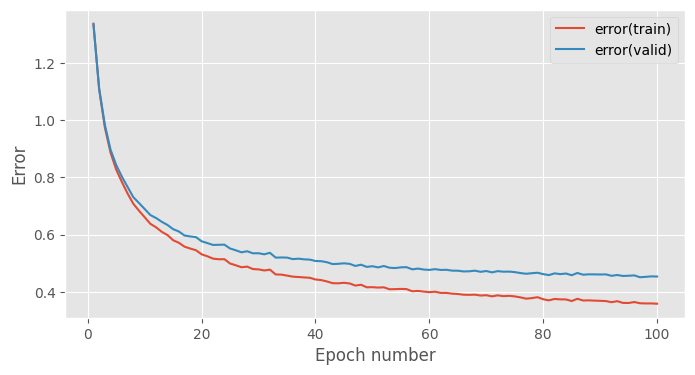

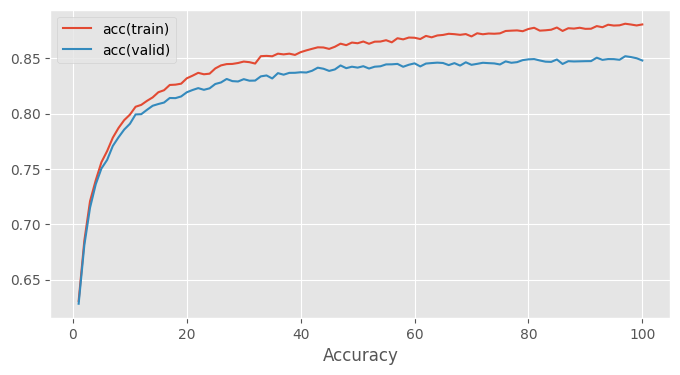

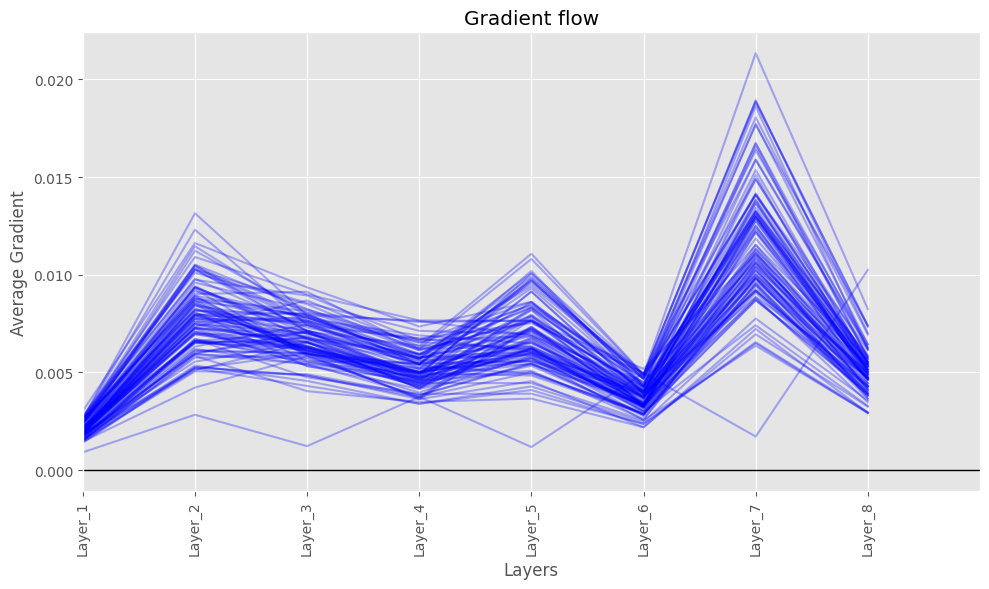

In [16]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_l1 = 0.001  # L1 coefficient
l2 = L2Penalty(lambda_l1)  # instantiate the L2 penalty

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l2, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Label Smoothing

In [18]:
# Create data provider objects for the MNIST data set
train_data_smooth = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=0.1)
valid_data_smooth = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=0.1)

KeysView(NpzFile 'C:\\Users\\andre\\Documents\\UoE\\mlpractical\\data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:\\Users\\andre\\Documents\\UoE\\mlpractical\\data\\emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.4s to complete
    error(train)=1.89e+00, acc(train)=6.35e-01, error(valid)=1.90e+00, acc(valid)=6.34e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.7s to complete
    error(train)=1.72e+00, acc(train)=6.92e-01, error(valid)=1.73e+00, acc(valid)=6.86e-01


...

Epoch 98: 1.9s to complete
    error(train)=1.02e+00, acc(train)=9.09e-01, error(valid)=1.16e+00, acc(valid)=8.52e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.9s to complete
    error(train)=1.02e+00, acc(train)=9.11e-01, error(valid)=1.16e+00, acc(valid)=8.49e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.9s to complete
    error(train)=1.02e+00, acc(train)=9.09e-01, error(valid)=1.16e+00, acc(valid)=8.49e-01


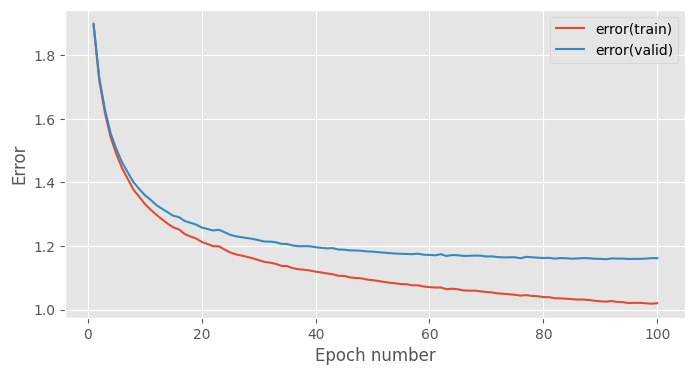

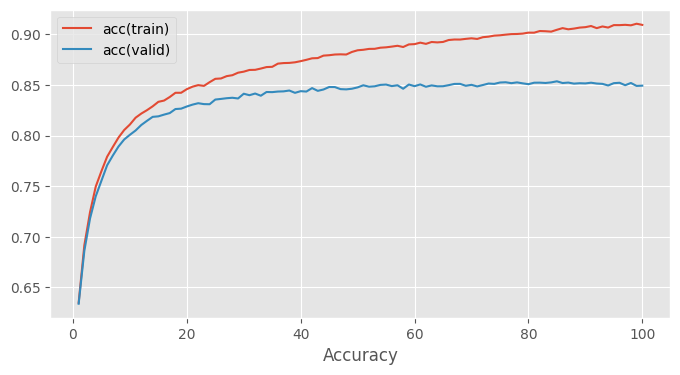

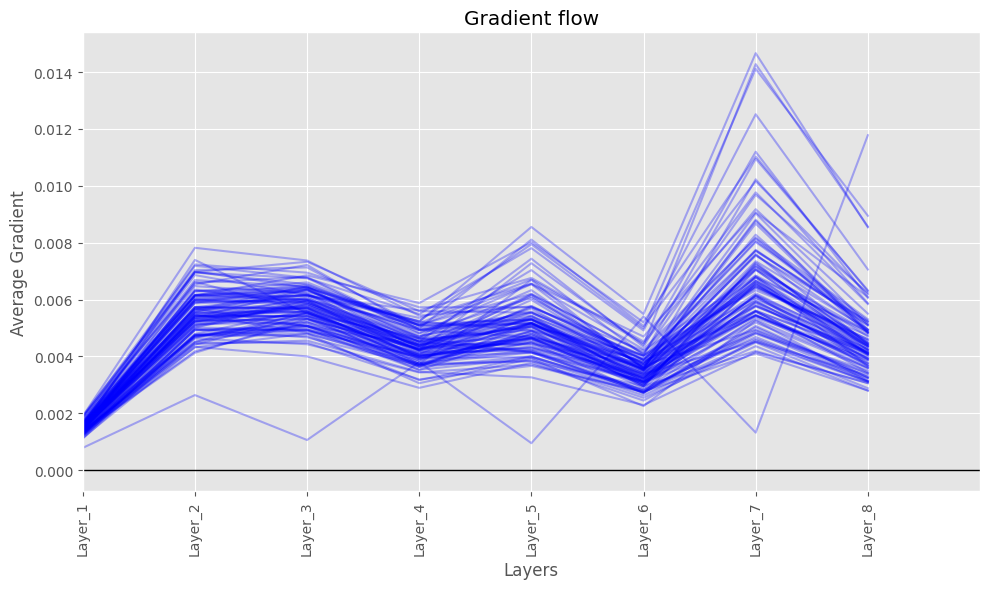

In [20]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  


# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_smooth, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data_smooth, valid_data_smooth, num_epochs, stats_interval, notebook=True)

## L1 + L2 Regularization

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.4s to complete
    error(train)=1.35e+00, acc(train)=6.27e-01, error(valid)=1.35e+00, acc(valid)=6.20e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.4s to complete
    error(train)=1.11e+00, acc(train)=6.84e-01, error(valid)=1.12e+00, acc(valid)=6.79e-01


...

Epoch 98: 1.4s to complete
    error(train)=2.53e-01, acc(train)=9.11e-01, error(valid)=5.09e-01, acc(valid)=8.38e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.6s to complete
    error(train)=2.53e-01, acc(train)=9.11e-01, error(valid)=5.14e-01, acc(valid)=8.40e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.5s to complete
    error(train)=2.51e-01, acc(train)=9.12e-01, error(valid)=5.16e-01, acc(valid)=8.40e-01


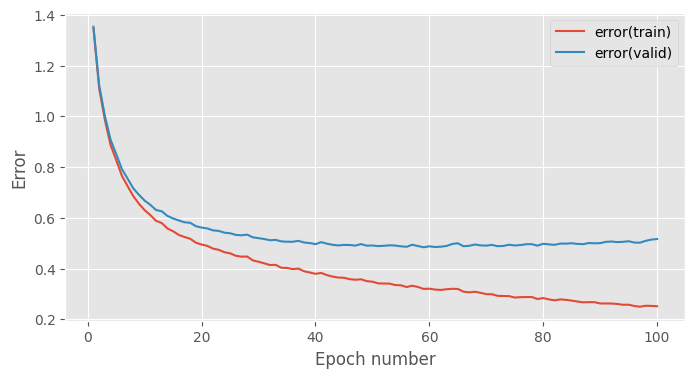

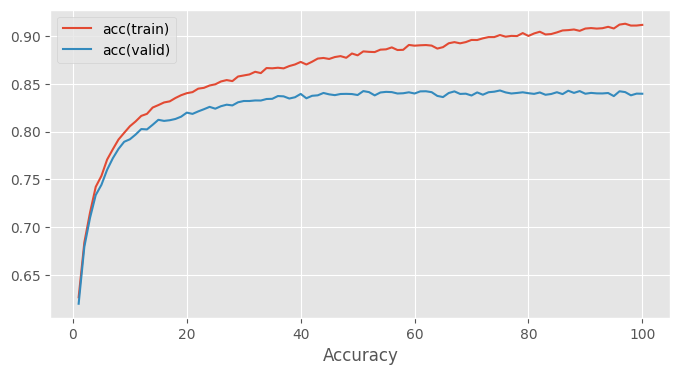

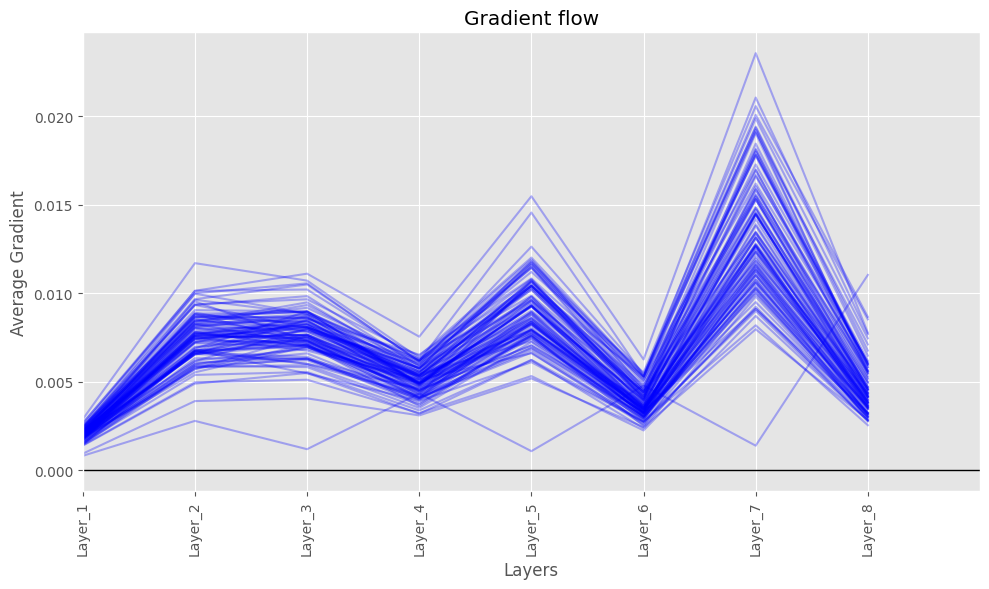

In [11]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_param = 1e-5 
alpha = 0.5
l1_l2 = L1L2MixPenalty(lambda_param, alpha)

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1_l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1_l2, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Accuracy and error by inclusion probability for Dropout

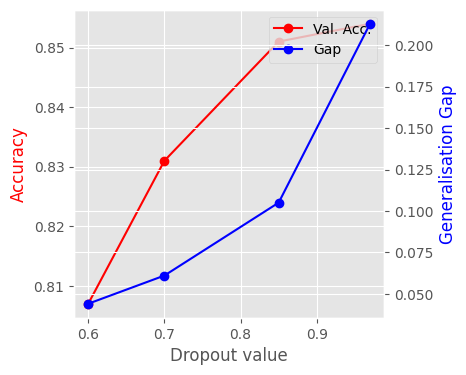

In [37]:
# plotting accuracy and error for dropout by inclusion probability

dropout_value = np.array([0.6,0.7,0.85,0.97])

val_accuracy = np.array([0.807,0.831,0.851,0.854])

train_error = np.array([0.549,0.448,0.329,0.244])

validation_error = np.array([0.593,0.509,0.434, 0.457])

gap = validation_error - train_error

# plot accuracy vs dropout inclusion probability and error gap vs dropout inclusion probability

fig, ax1 = plt.subplots(1,1, figsize=(4,4))
ax1.plot(dropout_value, val_accuracy, label='Val. Acc.', marker='o', color='red')
ax1.set_xlabel('Dropout value')
ax1.set_ylabel('Accuracy', color='red')
ax2 = ax1.twinx()
ax2.plot(dropout_value, gap, label='Gap', color='blue', marker='o')
ax2.set_ylabel('Generalisation Gap', color='blue')
# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.savefig('../report/figures/mlp_cw1_emnist_dropout_accuracy_gap.pdf',
            bbox_inches="tight", pad_inches=0.1)

## Accuracy and error by regularization strength for L1 & L2

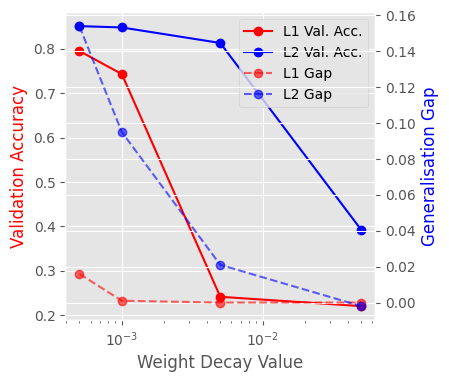

In [38]:
# plotting accuracy and error for dropout by inclusion probability

weight_decay = np.array([5e-4,1e-3,5e-3,5e-2])

val_accuracy_l1 = np.array([0.795,0.743,0.241,0.220])
val_accuracy_l2 = np.array([0.851,0.848,0.813,0.392])

train_error_l1 = np.array([0.642,0.879,3.850,3.850])
train_error_l2 = np.array([0.306,0.358,0.586,2.258])

validation_error_l1 = np.array([0.658,0.880,3.850,3.850])
validation_error_l2 = np.array([0.460,0.453,0.607,2.256])

l1_gap = validation_error_l1 - train_error_l1
l2_gap = validation_error_l2 - train_error_l2

# plot accuracy vs weight decay and error gap vs weight decay with dual axes

fig, ax1 = plt.subplots(1,1, figsize=(4,4))
ax1.plot(weight_decay, val_accuracy_l1, label='L1 Val. Acc.', marker='o', color='red')
ax1.plot(weight_decay, val_accuracy_l2, label='L2 Val. Acc.', marker='o', color='blue')
ax1.set_xlabel('Weight Decay Value')
ax1.set_ylabel('Validation Accuracy', color='red')
ax1.set_xscale('log')
ax2 = ax1.twinx()
ax2.plot(weight_decay, l1_gap, label='L1 Gap', marker='o', linestyle='--', color='red', alpha=0.6)
ax2.plot(weight_decay, l2_gap, label='L2 Gap', marker='o', linestyle='--', color='blue', alpha=0.6)
ax2.set_ylabel('Generalisation Gap', color='blue')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

fig.savefig('../report/figures/mlp_cw1_emnist_weightdecay_accuracy_gap.pdf',
            bbox_inches="tight", pad_inches=0.1)

# L1 | L2 Regularization Experiment


## R1

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.7s to complete
    error(train)=1.35e+00, acc(train)=6.23e-01, error(valid)=1.36e+00, acc(valid)=6.22e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.7s to complete
    error(train)=1.11e+00, acc(train)=6.88e-01, error(valid)=1.11e+00, acc(valid)=6.80e-01


...

Epoch 98: 2.8s to complete
    error(train)=3.09e-01, acc(train)=8.94e-01, error(valid)=4.53e-01, acc(valid)=8.50e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.8s to complete
    error(train)=3.09e-01, acc(train)=8.93e-01, error(valid)=4.57e-01, acc(valid)=8.48e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.6s to complete
    error(train)=3.09e-01, acc(train)=8.94e-01, error(valid)=4.55e-01, acc(valid)=8.51e-01


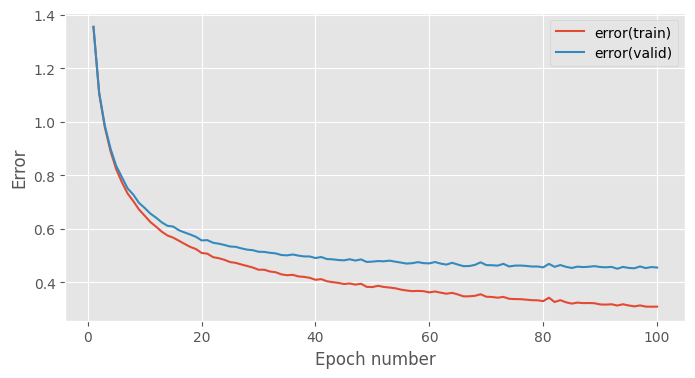

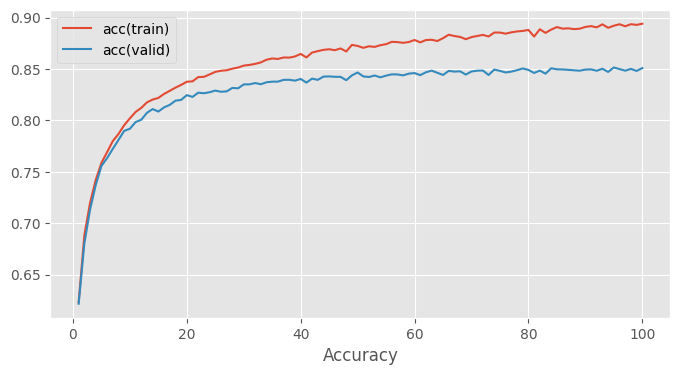

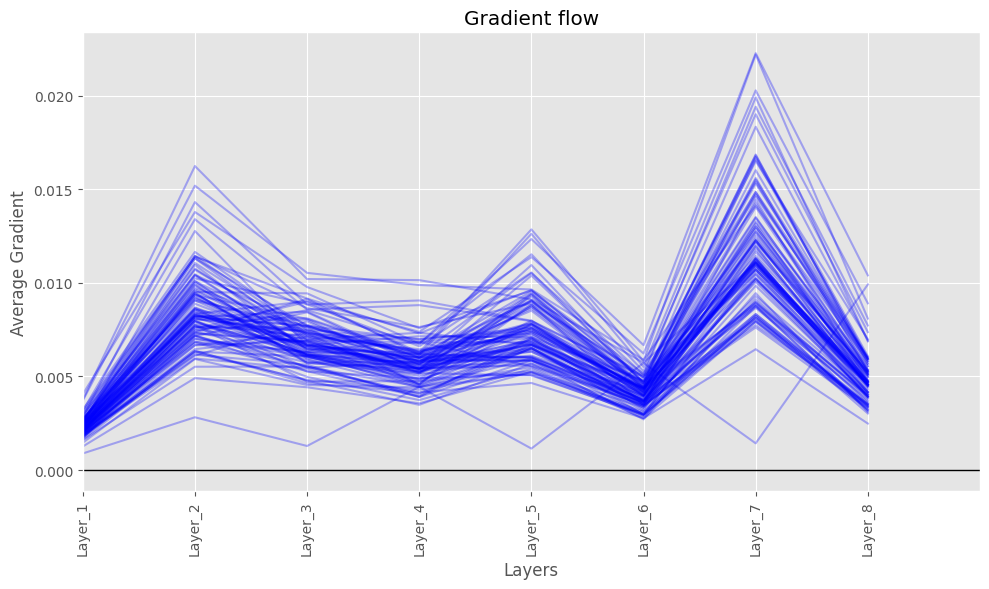

In [21]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_param = 5e-5 
alpha = 0.9
l1_l2 = L1L2MixPenalty(lambda_param, alpha)

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1_l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1_l2_1, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## R2

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.9s to complete
    error(train)=1.32e+00, acc(train)=6.30e-01, error(valid)=1.32e+00, acc(valid)=6.29e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.7s to complete
    error(train)=1.07e+00, acc(train)=6.93e-01, error(valid)=1.08e+00, acc(valid)=6.88e-01


...

Epoch 98: 2.7s to complete
    error(train)=3.05e-01, acc(train)=8.94e-01, error(valid)=4.55e-01, acc(valid)=8.51e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.7s to complete
    error(train)=3.09e-01, acc(train)=8.93e-01, error(valid)=4.60e-01, acc(valid)=8.49e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.7s to complete
    error(train)=3.05e-01, acc(train)=8.95e-01, error(valid)=4.55e-01, acc(valid)=8.51e-01


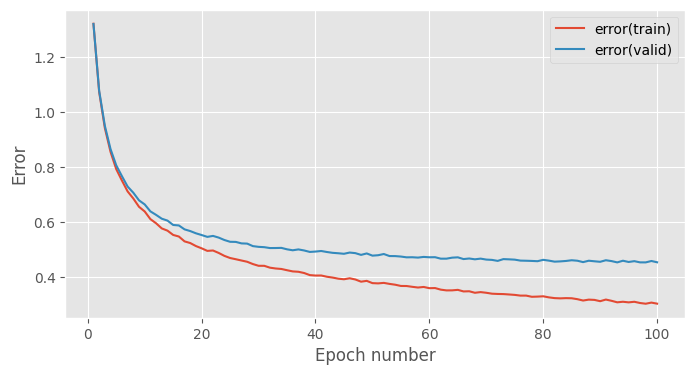

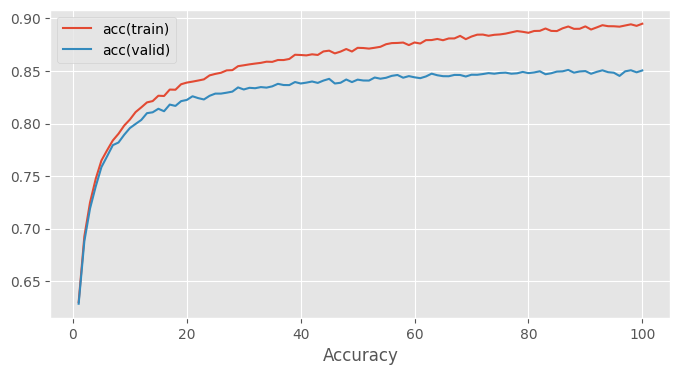

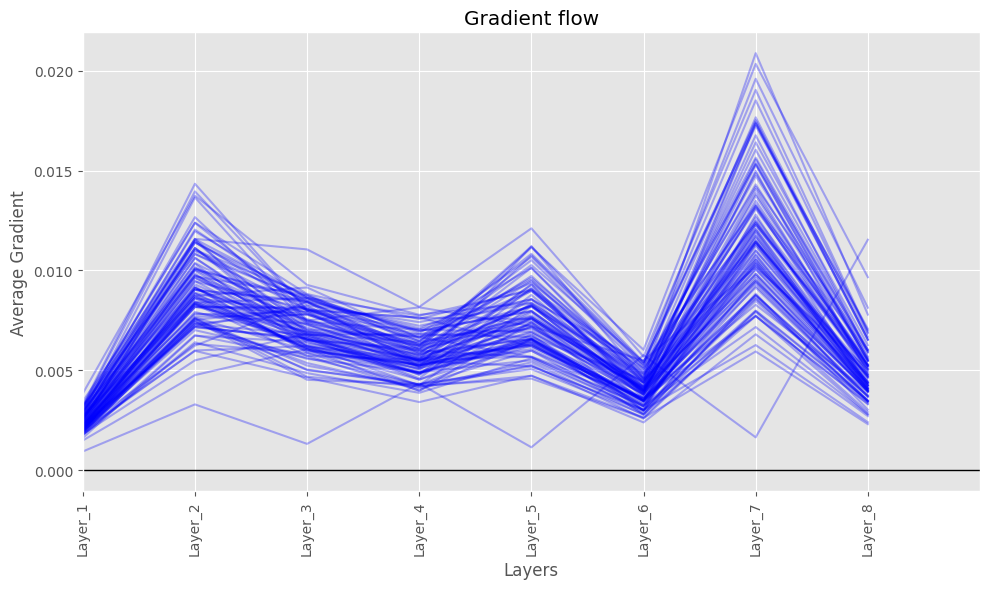

In [15]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_param = 5e-5 
alpha = 0.75
l1_l2 = L1L2MixPenalty(lambda_param, alpha)

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1_l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1_l2_2, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## R3

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.8s to complete
    error(train)=1.35e+00, acc(train)=6.26e-01, error(valid)=1.35e+00, acc(valid)=6.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.8s to complete
    error(train)=1.11e+00, acc(train)=6.86e-01, error(valid)=1.11e+00, acc(valid)=6.82e-01


...

Epoch 98: 2.7s to complete
    error(train)=2.90e-01, acc(train)=9.00e-01, error(valid)=4.61e-01, acc(valid)=8.49e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.7s to complete
    error(train)=2.89e-01, acc(train)=9.00e-01, error(valid)=4.62e-01, acc(valid)=8.48e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.7s to complete
    error(train)=2.84e-01, acc(train)=9.02e-01, error(valid)=4.59e-01, acc(valid)=8.50e-01


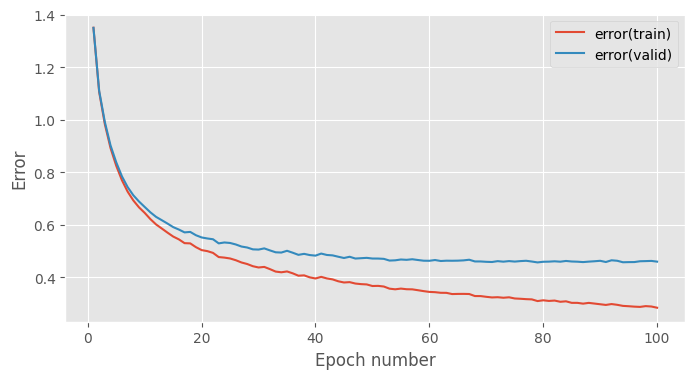

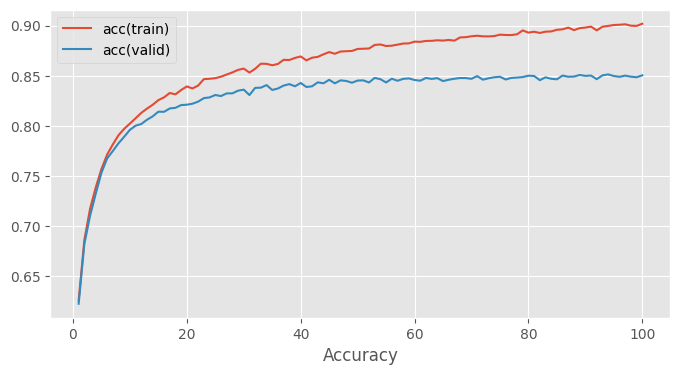

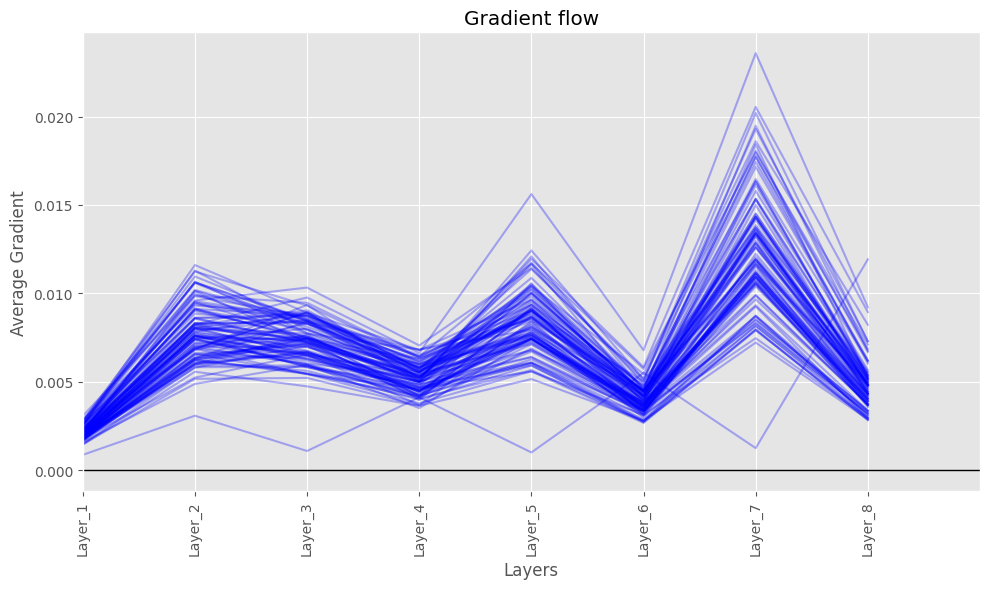

In [22]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_param = 5e-5 
alpha = 0.5
l1_l2 = L1L2MixPenalty(lambda_param, alpha)

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1_l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1_l2_3, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## R4

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.6s to complete
    error(train)=1.38e+00, acc(train)=6.19e-01, error(valid)=1.38e+00, acc(valid)=6.13e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.7s to complete
    error(train)=1.13e+00, acc(train)=6.80e-01, error(valid)=1.14e+00, acc(valid)=6.76e-01


...

Epoch 98: 2.4s to complete
    error(train)=2.79e-01, acc(train)=9.04e-01, error(valid)=4.86e-01, acc(valid)=8.44e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.6s to complete
    error(train)=2.78e-01, acc(train)=9.04e-01, error(valid)=4.87e-01, acc(valid)=8.43e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.7s to complete
    error(train)=2.77e-01, acc(train)=9.04e-01, error(valid)=4.88e-01, acc(valid)=8.42e-01


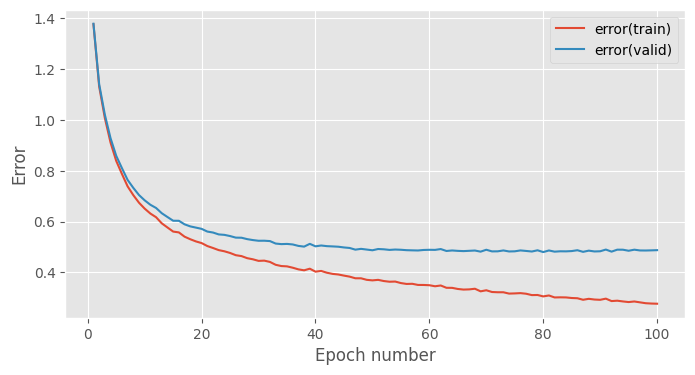

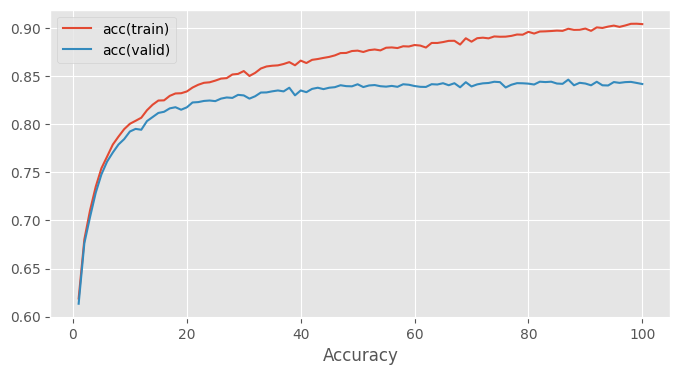

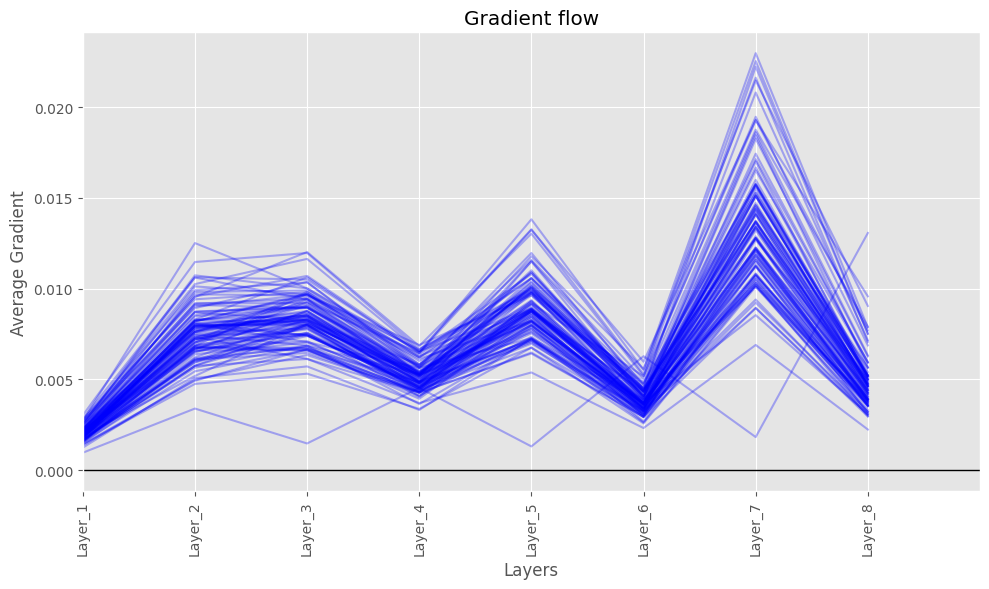

In [23]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)  

lambda_param = 5e-5 
alpha = 0.25
l1_l2 = L1L2MixPenalty(lambda_param, alpha)

# Create model with THREE hidden layers and apply L2 to weights
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=l1_l2), # third hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=l1_l2) # output layer
])

error = CrossEntropySoftmaxError()  
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_l1_l2_4, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [24]:
l1l2_train_error = [stats_l1_l2_1[:, keys['error(train)']][-1], stats_l1_l2_2[:, keys['error(train)']][-1],
                    stats_l1_l2_3[:, keys['error(train)']][-1], stats_l1_l2_4[:, keys['error(train)']][-1]]
l1l2_val_error = [stats_l1_l2_1[:, keys['error(valid)']][-1], stats_l1_l2_2[:, keys['error(valid)']][-1],
                  stats_l1_l2_3[:, keys['error(valid)']][-1], stats_l1_l2_4[:, keys['error(valid)']][-1]]
l1l2_gap = np.array(l1l2_val_error) - np.array(l1l2_train_error)

l1l2_accuracy_train = [stats_l1_l2_1[:, keys['acc(train)']][-1], stats_l1_l2_2[:, keys['acc(train)']][-1],
                       stats_l1_l2_3[:, keys['acc(train)']][-1], stats_l1_l2_4[:, keys['acc(train)']][-1]]

l1l2_accuracy_val = [stats_l1_l2_1[:, keys['acc(valid)']][-1], stats_l1_l2_2[:, keys['acc(valid)']][-1],
                     stats_l1_l2_3[:, keys['acc(valid)']][-1], stats_l1_l2_4[:, keys['acc(valid)']][-1]]


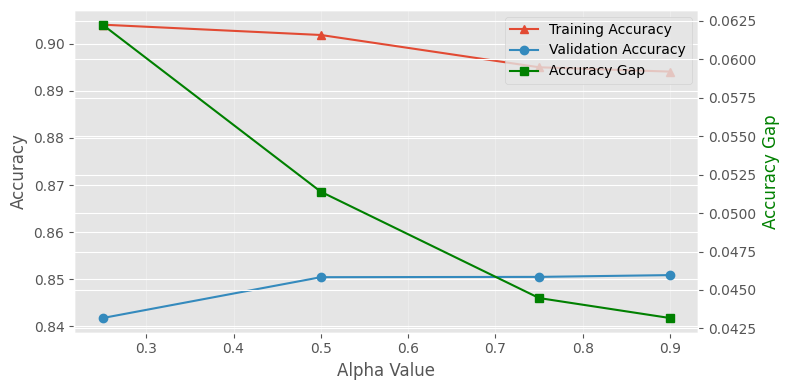

In [39]:
# compute accuracy gap (train - val) so positive = overfitting
gap_acc = np.array(l1l2_accuracy_train) - np.array(l1l2_accuracy_val)

x = np.array([.90,.75,.5,.25])

labels = [f'Exp {i+1}' for i in x]

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, l1l2_accuracy_train, marker='^', label='Training Accuracy')
ax.plot(x, l1l2_accuracy_val,   marker='o', label='Validation Accuracy')
ax.set_xlabel('Alpha Value')
ax.set_ylabel('Accuracy')

ax2 = ax.twinx()
ax2.plot(x, gap_acc, marker='s', color='green', label='Accuracy Gap')
ax2.set_ylabel('Accuracy Gap', color='green')

# one combined legend
lines, labs = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines+lines2, labs+labs2, loc='upper right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

fig.savefig('../report/figures/mlp_cw1_emnist_l1l2_accuracy_gap.pdf')

In [26]:
alpha_values = [0.9, 0.75, 0.5, 0.25]

In [27]:
lambda_values = 1e-5

In [28]:
l1l2_accuracy_val

[np.float64(0.850886075949367),
 np.float64(0.8505063291139244),
 np.float64(0.8504430379746836),
 np.float64(0.8417721518987332)]

In [29]:
l1l2_train_error

[np.float64(0.3090380482083173),
 np.float64(0.3048001055542566),
 np.float64(0.28396712784637307),
 np.float64(0.2769612043329377)]

In [30]:
l1l2_val_error

[np.float64(0.4550601876103765),
 np.float64(0.4549515264219221),
 np.float64(0.45940489853894145),
 np.float64(0.4876239552575954)]

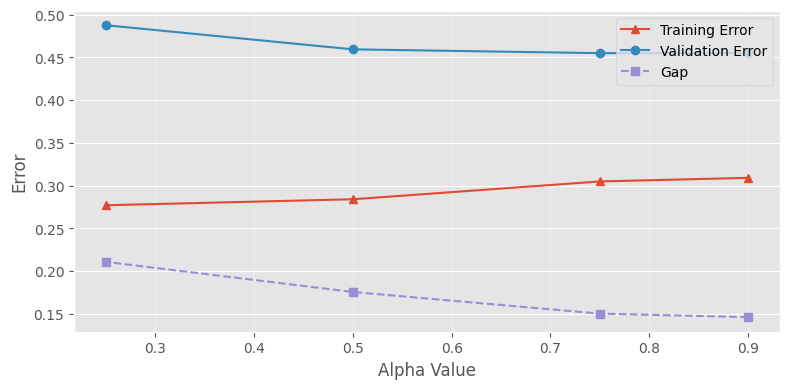

In [31]:
# errors and their gap (val − train) so positive = overfitting
gap_err = np.array(l1l2_val_error) - np.array(l1l2_train_error)

x = np.array([.90,.75,.5,.25])
labels = [f'Exp {i+1}' for i in x]

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, l1l2_train_error, marker='^', label='Training Error')
ax.plot(x, l1l2_val_error,   marker='o', label='Validation Error')
ax.set_xlabel('Alpha Value')


ax.set_ylabel('Error')

ax.plot(x, gap_err, marker='s', linestyle='--', label='Gap')


lines, labs = ax.get_legend_handles_labels()
ax.legend(lines, labs, loc='upper right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

fig.savefig('../report/figures/mlp_cw1_emnist_l1l2_error_gap.pdf')


## Run Best Configurations on Test Set

In [18]:
#load test data
test_data = EMNISTDataProvider('test', batch_size=batch_size, rng=rng)

KeysView(NpzFile 'C:\\Users\\andre\\Documents\\UoE\\mlpractical\\data\\emnist-test.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=1.42e+00, acc(train)=6.08e-01, error(valid)=1.42e+00, acc(valid)=6.07e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 1.8s to complete
    error(train)=1.16e+00, acc(train)=6.70e-01, error(valid)=1.17e+00, acc(valid)=6.63e-01


...

Epoch 98: 1.8s to complete
    error(train)=2.45e-01, acc(train)=9.12e-01, error(valid)=4.39e-01, acc(valid)=8.56e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.8s to complete
    error(train)=2.43e-01, acc(train)=9.12e-01, error(valid)=4.40e-01, acc(valid)=8.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.8s to complete
    error(train)=2.41e-01, acc(train)=9.12e-01, error(valid)=4.37e-01, acc(valid)=8.56e-01


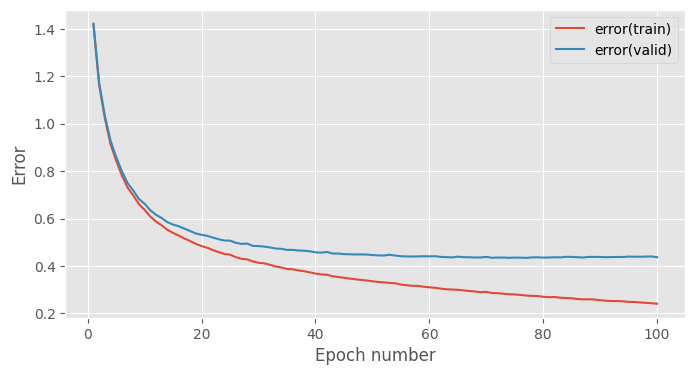

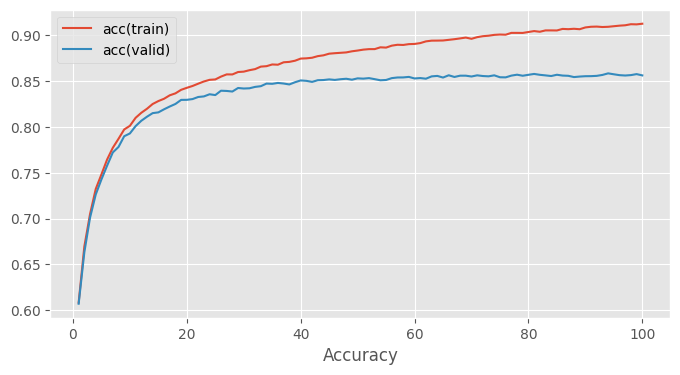

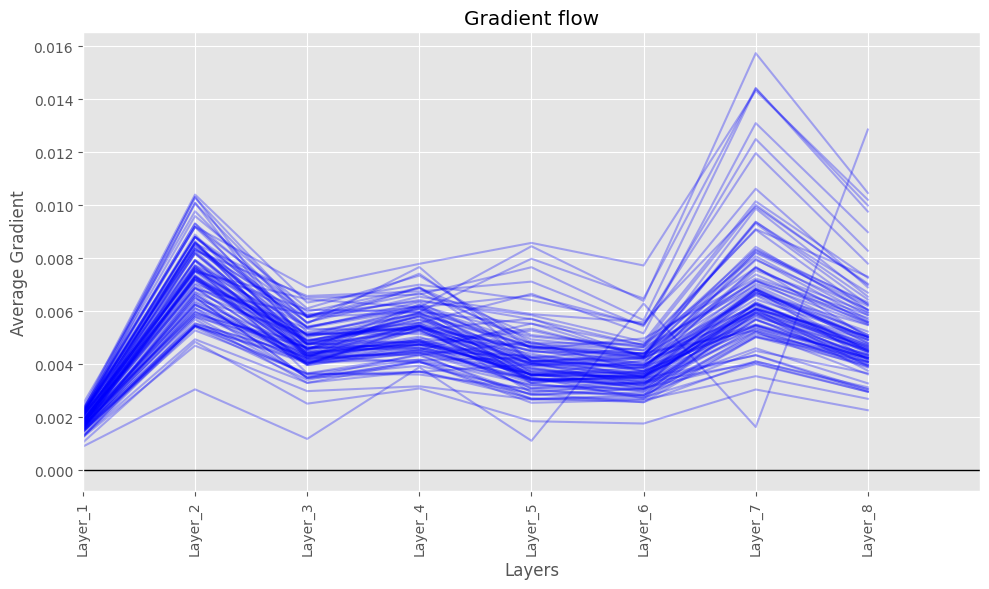

In [19]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128 # changed hidden dim to 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

p = 0.97  # dropout probability

# Create model with TWO hidden layers
model_dropout_best = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after first hidden layer
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after second hidden layer
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # third hidden layer
    ReluLayer(),
    DropoutLayer(rng, p),  # dropout after third hidden layer
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats_Dropout_best, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model_dropout_best, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [20]:
test_err, test_acc = 0.0, 0.0
for inputs, targets in test_data:
    outputs = model_dropout_best.fprop(inputs, evaluation=True)[-1]
    test_err += error(outputs, targets)
    test_acc += (outputs.argmax(-1) == targets.argmax(-1)).mean()

test_err /= test_data.num_batches
test_acc /= test_data.num_batches
print(f"Test error: {test_err:.4f}, test accuracy: {test_acc:.4f}")

Test error: 0.4794, test accuracy: 0.8465


# Question 9

In [19]:
l1l2_train_error

[np.float64(0.25217999566847205),
 np.float64(0.2680766482770191),
 np.float64(0.250297134006699),
 np.float64(0.2674731588302881)]

In [20]:
l1l2_val_error

[np.float64(0.4859223583367313),
 np.float64(0.4689089584241287),
 np.float64(0.5066615125513223),
 np.float64(0.4877666762697881)]

In [15]:
l1l2_gap

array([0.23374236, 0.20083231, 0.25636438, 0.22029352])

In [16]:
l1l2_accuracy_train

[np.float64(0.9127499999999971),
 np.float64(0.905689999999997),
 np.float64(0.912269999999997),
 np.float64(0.9063999999999961)]

In [18]:
l1l2_accuracy_val

[np.float64(0.846392405063291),
 np.float64(0.8472151898734182),
 np.float64(0.8398734177215189),
 np.float64(0.8428481012658225)]

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 2.3s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 2.3s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.02e-02


...

Epoch 8: 2.3s to complete
    error(train)=3.85e+00, acc(train)=2.17e-02, error(valid)=3.85e+00, acc(valid)=1.96e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 9: 2.2s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.03e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 10: 2.3s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.02e-02


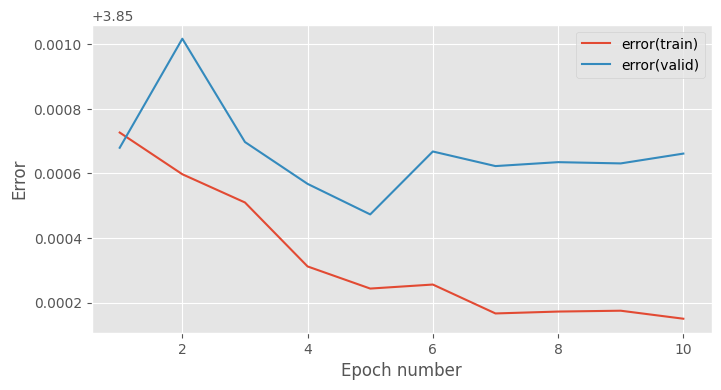

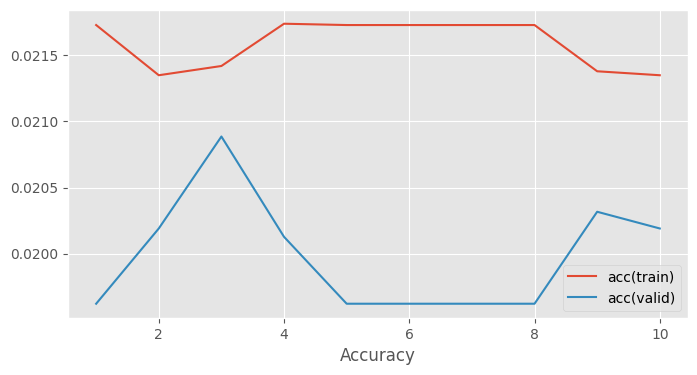

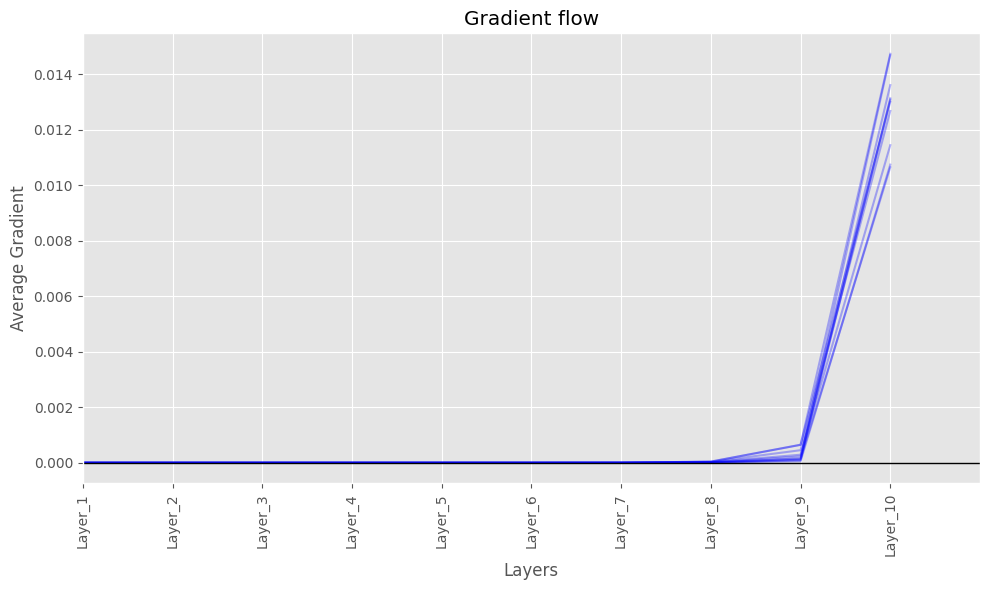

In [34]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 10
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

In [34]:
# You can then check the plots like this
fig_1 # The training error plot
fig_1.savefig('../report/figures/mlp_cw1_emnist_custom_activation_error.pdf')

In [35]:
fig_2 # The training accuracy plot
fig_2.savefig('../report/figures/mlp_cw1_emnist_custom_activation_accuracy.pdf')

In [36]:
grad_plot # The gradient flow plot
grad_plot.savefig('../report/figures/mlp_cw1_emnist_custom_activation_gradients.pdf')